In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
# Connect to in-memory SQLite DB (you can also use 'sales_data.db' to persist)
conn = sqlite3.connect(':memory:')
cursor = conn.cursor()

# Create table
cursor.execute('''
    CREATE TABLE sales (
        id INTEGER PRIMARY KEY AUTOINCREMENT,
        product TEXT NOT NULL,
        quantity INTEGER NOT NULL,
        price REAL NOT NULL
    )
''')

# Insert sample data
sample_data = [
    ('Apples', 10, 0.5),
    ('Bananas', 20, 0.3),
    ('Oranges', 15, 0.4),
    ('Apples', 5, 0.5),
    ('Bananas', 10, 0.3),
    ('Oranges', 10, 0.4),
]
cursor.executemany('INSERT INTO sales (product, quantity, price) VALUES (?, ?, ?)', sample_data)
conn.commit()


In [3]:
query = '''
    SELECT
        product,
        SUM(quantity) AS total_quantity,
        ROUND(SUM(quantity * price), 2) AS revenue
    FROM sales
    GROUP BY product
'''
df = pd.read_sql_query(query, conn)
print("Sales Summary:")
print(df)


Sales Summary:
   product  total_quantity  revenue
0   Apples              15      7.5
1  Bananas              30      9.0
2  Oranges              25     10.0


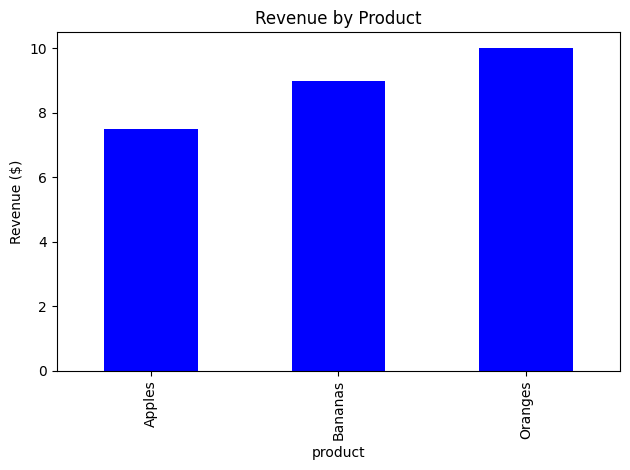

In [9]:
df.plot(kind='bar', x='product', y='revenue', title='Revenue by Product', legend=False, color='blue')
plt.ylabel("Revenue ($)")
plt.tight_layout()
plt.show()


In [10]:
plt.show()  # Required in Google Colab to display the chart
